## Word Matching with a bipartite weighted graph

In this section, we'll show the matching of our reference sentence to the hypothesis transcript. The alignment is modelled as finding the min-cost max-flow in a bipartite network.

In [1]:
import sys
import importlib
from pathlib import Path

# locate project root by walking up until requirements.txt is found
_anchor = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in (_anchor, *_anchor.parents) if (p / "requirements.txt").exists())
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "domain"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "utils"))

import pandas as pd

import preprocessing
import word_similarity_calculator
import bipartite_matching
import plot_helpers
importlib.reload(preprocessing)
importlib.reload(word_similarity_calculator)
importlib.reload(bipartite_matching)
importlib.reload(plot_helpers)

from word_similarity_calculator import WordSimilarityCalculator
from bipartite_matching import build_full_bipartite_graph, solve_matching, get_node_name, extract_index_from_node_name, REFERENCE_PARTITION, ATTR_WORD, ATTR_SIMILARITY
from preprocessing import clean_word
from plot_helpers import plot_bipartite_graph_full, plot_reduced_bipartite_graph_with_matching

In [2]:
# Pick a sentence by path (from STT4SG-350 train_all) and align it against BOTH DIT and DAT.
SENTENCE_PATH = "b74db39e-7b8a-4ee0-990f-4aef5e98e10b/52f1a3177af9487a7b25a517bdbb2fc7cf86b544307f4aa94c162198ef397350.flac"

DAT_TSV = PROJECT_ROOT / "transcripts" / "dialect-aware" / "fhnw" / "stt4sg" / "train_all_transcribed.tsv"
DIT_TSV = PROJECT_ROOT / "transcripts" / "dialect-ignorant" / "whisper-large-v2" / "stt4sg" / "train_all_enriched_transcribed_praet.tsv"

dat = pd.read_csv(DAT_TSV, sep="\t", encoding="utf-8-sig",
                  usecols=["path", "sentence", "fhnw_transcript", "dialect_region"]).set_index("path")
dit = pd.read_csv(DIT_TSV, sep="\t", encoding="utf-8-sig",
                  usecols=["path", "whisper_large_v2_transcript"]).set_index("path")

reference = dat.loc[SENTENCE_PATH, "sentence"]
dit_hypothesis = dit.loc[SENTENCE_PATH, "whisper_large_v2_transcript"]
dat_hypothesis = dat.loc[SENTENCE_PATH, "fhnw_transcript"]

print(f"Path:       {SENTENCE_PATH}  ({dat.loc[SENTENCE_PATH, 'dialect_region']})")
print(f"Reference:  {reference}")
print(f"DIT hyp:    {dit_hypothesis}")
print(f"DAT hyp:    {dat_hypothesis}")


def tokenize(text: str) -> list[str]:
    return [w for w in (clean_word(t) for t in text.split()) if w]


def run_alignment(ref_tokens, hyp_tokens):
    # Calibrated hyperparameters — must match build_alignment_table.py.
    calc = WordSimilarityCalculator(
        alpha=0.85, lambda_=0.45,
        use_global_lexical_normalization=False, use_squared_positional=True,
        sent_len=max(len(ref_tokens), len(hyp_tokens)),
    )
    G = build_full_bipartite_graph(ref_tokens, hyp_tokens, calc)
    matching = solve_matching(G)
    return G, matching


def alignment_df(ref_tokens, hyp_tokens, G, matching):
    n_r, n_h = len(ref_tokens), len(hyp_tokens)
    hypothesis_row, similarity_row = [], []
    for i in range(n_r):
        hyp_node = matching[get_node_name(REFERENCE_PARTITION, i)]
        hyp_word = G.nodes[hyp_node][ATTR_WORD]
        similarity = G.edges[get_node_name(REFERENCE_PARTITION, i), hyp_node][ATTR_SIMILARITY]
        if similarity is not None:
            hyp_idx = extract_index_from_node_name(hyp_node)
            hypothesis_row.append(f"{hyp_word} [{hyp_idx + 1}]")
            similarity_row.append(f"{similarity:.3f}")
        else:
            hypothesis_row.append(hyp_word)
            similarity_row.append("ε")
    df = pd.DataFrame(
        [list(ref_tokens), hypothesis_row, list(hyp_tokens), similarity_row],
        index=["Reference", "Hypothesis (matched)", "Hypothesis (original)", "Similarity"],
    )
    df.columns = range(1, max(n_h, n_r) + 1)
    return df


ref = tokenize(reference)
dit_hyp = tokenize(dit_hypothesis)
dat_hyp = tokenize(dat_hypothesis)

G_dit, matching_dit = run_alignment(ref, dit_hyp)
G_dat, matching_dat = run_alignment(ref, dat_hyp)

print("\n=== DIT alignment ===")
display(alignment_df(ref, dit_hyp, G_dit, matching_dit))
print("\n=== DAT alignment ===")
display(alignment_df(ref, dat_hyp, G_dat, matching_dat))

Path:       b74db39e-7b8a-4ee0-990f-4aef5e98e10b/52f1a3177af9487a7b25a517bdbb2fc7cf86b544307f4aa94c162198ef397350.flac  (Bern)
Reference:  Daraufhin lagen ein Mitfahrer und ein Pferd am Boden.
DIT hyp:    Darauf sind ein Mitfahrer und ein Pferd am Boden gelegen.
DAT hyp:    Daraufhin lagen ein Mitfahrer und ein Pferd am Boden.

=== DIT alignment ===


,1,2,3,4,5,6,7,8,9,10
Reference,daraufhin,lagen,ein,mitfahrer,und,ein,pferd,am,boden,NaN
Hypothesis (matched),darauf [1],gelegen [10],ein [3],mitfahrer [4],und [5],ein [6],pferd [7],am [8],boden [9],NaN
Hypothesis (original),darauf,sind,ein,mitfahrer,und,ein,pferd,am,boden,gelegen
Similarity,0.830,0.569,1.000,1.000,1.000,1.000,1.000,1.000,1.000,NaN



=== DAT alignment ===


,1,2,3,4,5,6,7,8,9
Reference,daraufhin,lagen,ein,mitfahrer,und,ein,pferd,am,boden
Hypothesis (matched),daraufhin [1],lagen [2],ein [3],mitfahrer [4],und [5],ein [6],pferd [7],am [8],boden [9]
Hypothesis (original),daraufhin,lagen,ein,mitfahrer,und,ein,pferd,am,boden
Similarity,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## Visualization

### Complete Graph

--- DIT ---


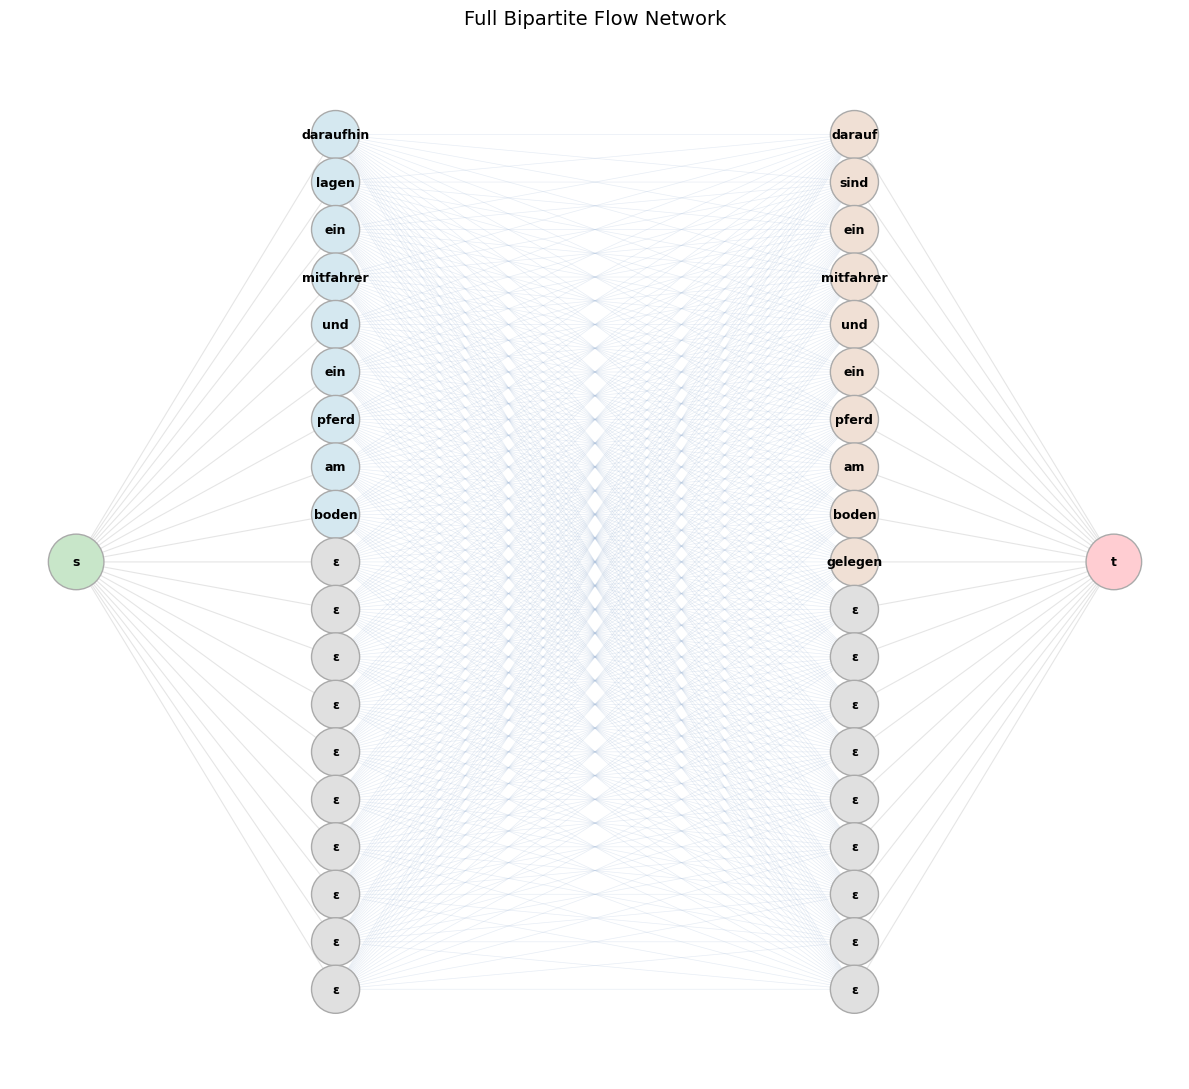

--- DAT ---


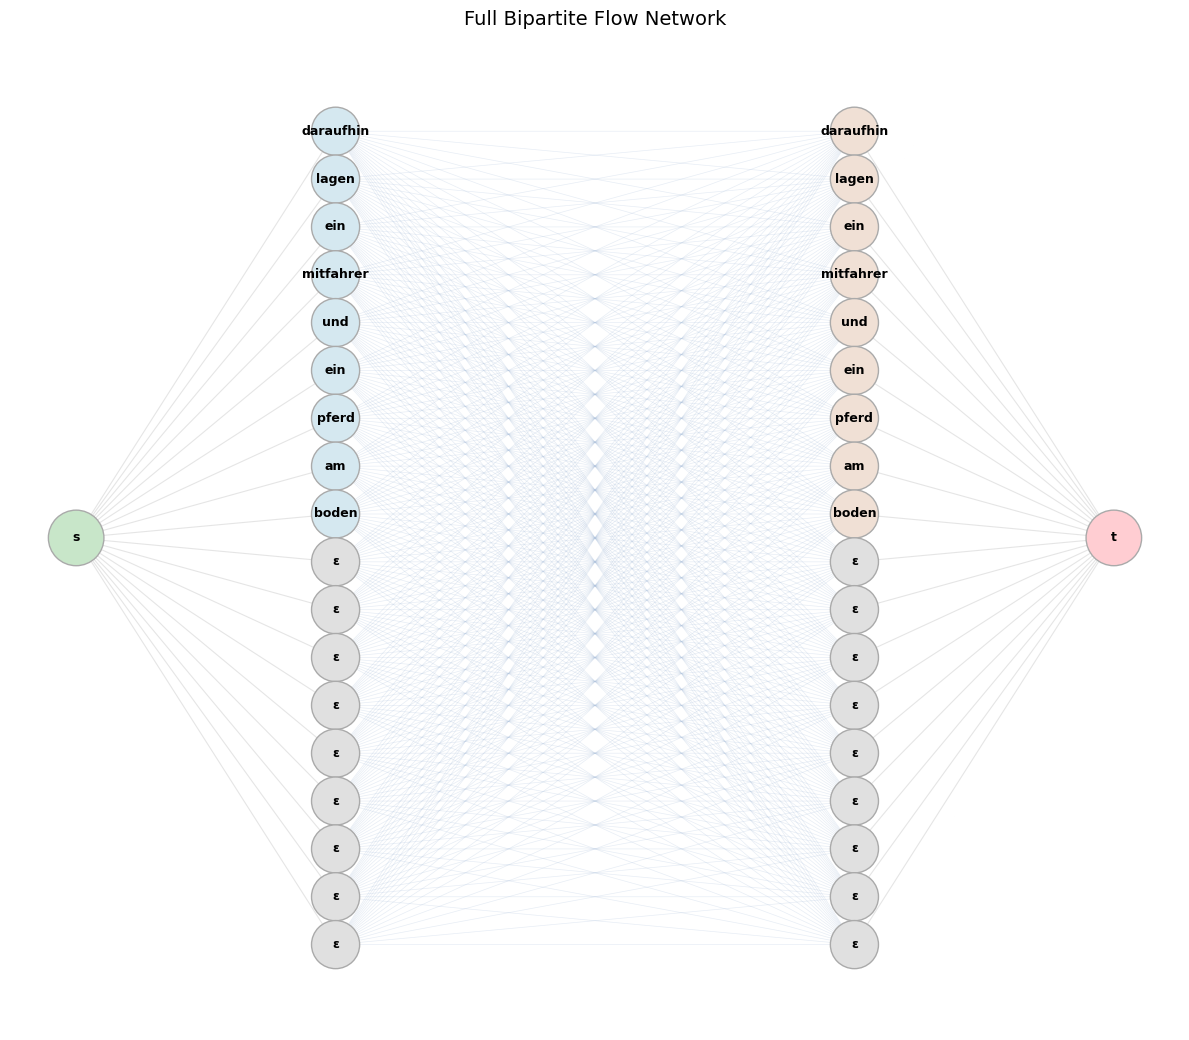

In [3]:
print("--- DIT ---")
plot_bipartite_graph_full(G_dit)
print("--- DAT ---")
plot_bipartite_graph_full(G_dat)

### Reduced Graph with Matching

--- DIT ---
--- DAT ---


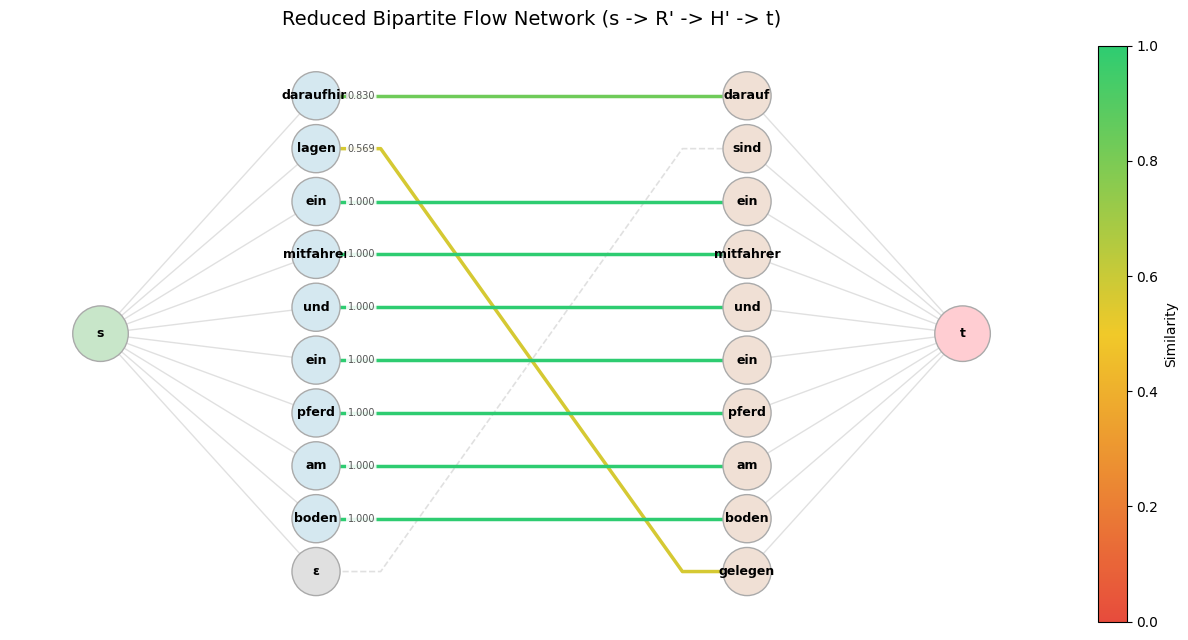

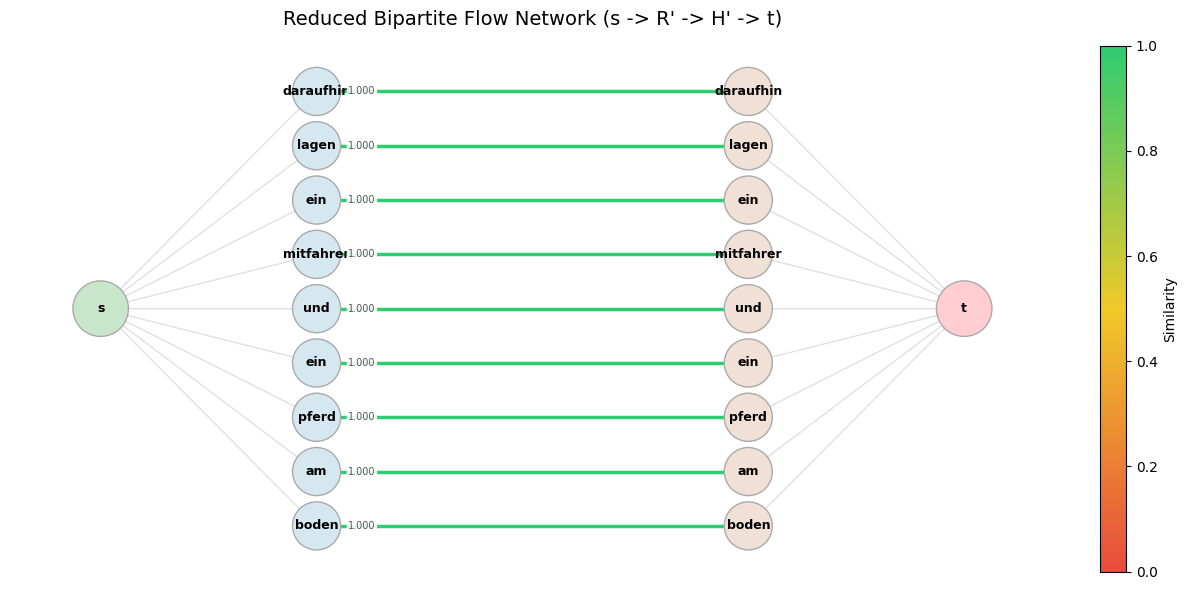

In [4]:
print("--- DIT ---")
plot_reduced_bipartite_graph_with_matching(G_dit, matching_dit)
print("--- DAT ---")
plot_reduced_bipartite_graph_with_matching(G_dat, matching_dat);